Primer Parcial

Estudiante: Chelsea Melany Espinoza Cava

Carrera: Ing. de Sistemas

Predice si los ingresos anuales de una persona superan los 50 000 dólares al año basándote en datos del censo. También conocido como conjunto de datos de "Ingresos del Censo".

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [12]:
# 1. DEFINIR COLUMNAS (El archivo .data no tiene encabezados)
columnas = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 
            'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 
            'hours-per-week', 'native-country', 'income']

# 2. CARGAR ARCHIVOS (Skipinitialspace quita espacios raros)
df_train = pd.read_csv('adult.data', names=columnas, sep=',', skipinitialspace=True)
df_test = pd.read_csv('adult.test', names=columnas, sep=',', skipinitialspace=True, skiprows=1)

In [13]:
# --- ANTES DE LA LIMPIEZA ---
print("--- Diagnóstico Inicial de Nulos ---")
nulos_antes = df_train.isnull().sum()
print(nulos_antes[nulos_antes > 0]) # Solo muestra las que tienen huecos

total_nulos_antes = df_train.isnull().sum().sum()
print(f"\nTOTAL DE HUECOS DETECTADOS: {total_nulos_antes}")

--- Diagnóstico Inicial de Nulos ---
Series([], dtype: int64)

TOTAL DE HUECOS DETECTADOS: 0


In [16]:
# CODIFICACIÓN (Letra a Número)
le = LabelEncoder()
for col in columnas:
    if df_train[col].dtype == 'object':
        df_train[col] = le.fit_transform(df_train[col].astype(str))
        # Usamos transform en el test para mantener la misma lógica
        df_test[col] = le.transform(df_test[col].astype(str))

In [17]:
# Fundamental porque 'capital-gain' llega a 99,999 y 'age' a 90
scaler = StandardScaler()

# Separamos X y y antes de escalar para no normalizar la respuesta (target)
X_train_raw = df_train.drop('income', axis=1)
y_train = df_train['income'].values

X_test_raw = df_test.drop('income', axis=1)
y_test = df_test['income'].values

# Escalamos las X
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

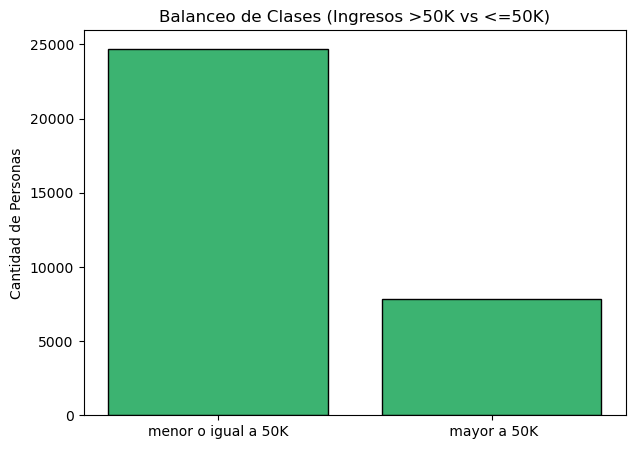

In [20]:
plt.figure(figsize=(7, 5))
plt.hist(y_train, bins=2, color='mediumseagreen', edgecolor='black', rwidth=0.8)
plt.title('Balanceo de Clases (Ingresos >50K vs <=50K)')
plt.xticks([0.25, 0.75], ['menor o igual a 50K', ' mayor a 50K'])
plt.ylabel('Cantidad de Personas')
plt.show()

In [19]:
print(f"Registros de Entrenamiento (X_train): {X_train.shape}")
print(f"Registros de Prueba (X_test): {X_test.shape}")
print(f"¿Hay nulos finales?: {np.isnan(X_train).sum()}")

Registros de Entrenamiento (X_train): (32561, 14)
Registros de Prueba (X_test): (16281, 14)
¿Hay nulos finales?: 0
